In [2]:
!pip install wordcloud

Defaulting to user installation because normal site-packages is not writeable


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


  label                                             review
0   pos  Stuning even for the non-gamer: This sound tra...
1   pos  The best soundtrack ever to anything.: I'm rea...
2   pos  Amazing!: This soundtrack is my favorite music...
3   pos  Excellent Soundtrack: I truly like this soundt...
4   pos  Remember, Pull Your Jaw Off The Floor After He...
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   10000 non-null  object
 1   review  10000 non-null  object
dtypes: object(2)
memory usage: 156.4+ KB
None
label
neg    5097
pos    4903
Name: count, dtype: int64


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\NIKHIL\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


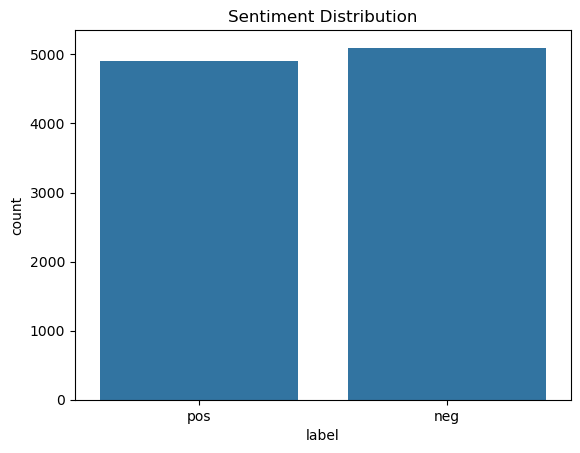

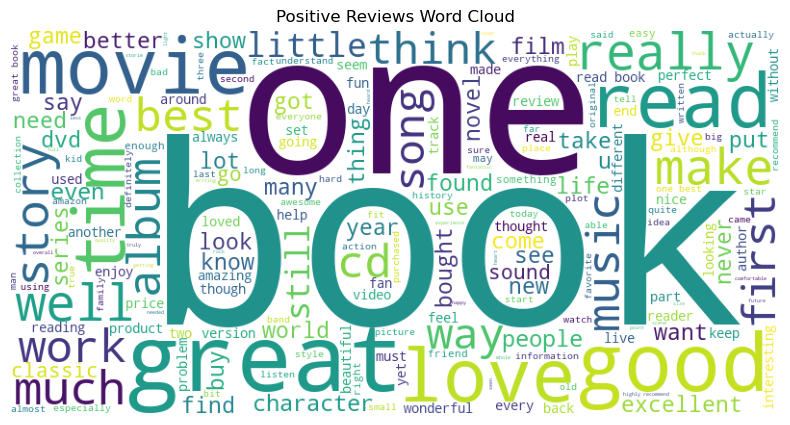

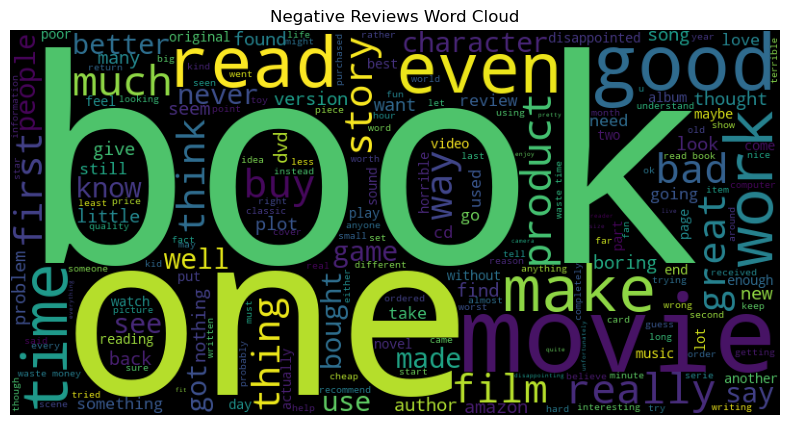

Accuracy: 0.851
              precision    recall  f1-score   support

         neg       0.85      0.86      0.86      1037
         pos       0.85      0.84      0.84       963

    accuracy                           0.85      2000
   macro avg       0.85      0.85      0.85      2000
weighted avg       0.85      0.85      0.85      2000

Accuracy: 0.8525
              precision    recall  f1-score   support

         neg       0.86      0.85      0.86      1037
         pos       0.84      0.85      0.85       963

    accuracy                           0.85      2000
   macro avg       0.85      0.85      0.85      2000
weighted avg       0.85      0.85      0.85      2000



C:\ProgramData\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10) reached and the optimization hasn't converged yet.
  warnings.warn(


Accuracy: 0.8515
              precision    recall  f1-score   support

         neg       0.85      0.86      0.86      1037
         pos       0.85      0.84      0.84       963

    accuracy                           0.85      2000
   macro avg       0.85      0.85      0.85      2000
weighted avg       0.85      0.85      0.85      2000



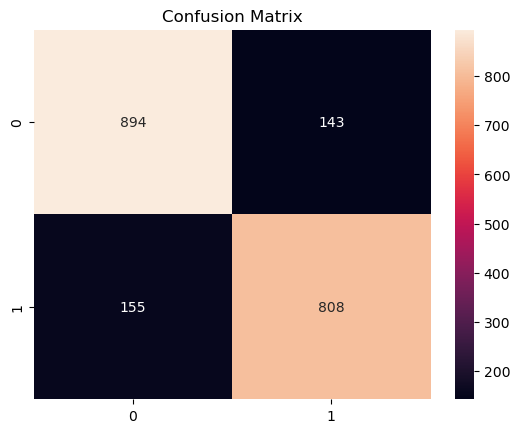

Cross Validation Accuracy: 0.8424999999999999


In [3]:
import pandas as pd

# Load dataset
df = pd.read_csv(r"C:\Users\NIKHIL\Downloads\data science assignment\data science assignment\amazonreviews.tsv", sep='\t')

# View basic info
print(df.head())
print(df.info())
print(df['label'].value_counts())

df.drop_duplicates(inplace=True)

df.isnull().sum()
df.dropna(inplace=True)

import re
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    text = text.split()
    text = [word for word in text if word not in stop_words]
    text = " ".join(text)
    return text

df['clean_review'] = df['review'].apply(preprocess_text)

import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='label', data=df)
plt.title("Sentiment Distribution")
plt.show()

from wordcloud import WordCloud

positive_text = " ".join(df[df['label']=='pos']['clean_review'])

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(positive_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis('off')
plt.title("Positive Reviews Word Cloud")
plt.show()

negative_text = " ".join(df[df['label']=='neg']['clean_review'])

wordcloud = WordCloud(width=800, height=400, background_color='black').generate(negative_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis('off')
plt.title("Negative Reviews Word Cloud")
plt.show()

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)
X = tfidf.fit_transform(df['clean_review'])
y = df['label']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train,y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

lr = LogisticRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

from sklearn.svm import LinearSVC

svm = LinearSVC()
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(hidden_layer_sizes=(100,), max_iter=10)
mlp.fit(X_train, y_train)
y_pred_mlp = mlp.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_mlp))
print(classification_report(y_test, y_pred_mlp))

from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

from sklearn.model_selection import cross_val_score

scores = cross_val_score(lr, X, y, cv=5)
print("Cross Validation Accuracy:", scores.mean())



Observations :

Majority of reviews are positive.
Negative reviews often mention:
Delivery issues
Poor quality
Defective products

Business Recommendations :

Monitor products with sudden negative spikes.
Auto-alert customer support for highly negative keywords.
Improve logistics if delivery complaints rise.
Use dashboard for real-time monitoring.
